In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\utils'))
sys.path.append(os.path.join(now_dir, r'models\aln_thalamus'))
# sys.path.append(os.path.join(now_dir, r'models\thalamus'))
# sys.path.append(os.path.join(now_dir, r'models\demo_model'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
'''
parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'model': ['thalamus']
}) # {'a': [...], 'b': [...], 'model': [...]}
parametrization_demo = pp.cartesian_product({
    'g_h': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'g_LK': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'model': ['thalamus']
})
type(parametrization_demo['g_h'][0]) # np.linspace will cause the type of number to be np.float64, which is conflicted with later computation?
'''

parametrization_demo = pp.cartesian_product({
    #'mue_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 251)],
    'mue_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 21)],
    #'mui_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 251)],
    'mui_ext_mean': [float(round(elem, 3)) for elem in np.linspace(0.0, 3.0, 21)],
    # 'model': ['aln']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [3]:
import defaultParameters as dp
params = dp.loadDefaultParams()
params['dt'] = 0.1
# params['fast_interp'] = 1
# params['global_delay'] = 1 # when it turns to 0, the program will get error?
# params['distr_delay'] = 0

params['c_gl'] = 0.40

# params['ext_exc_rate'] = 0.0
# params['ext_exc_current'] = 0.0

params['a'] = 0.0
params['b'] = 0.0

params['Jee_max'] = 2.43
params['Jii_max'] = -1.64
params['Jie_max'] = 2.60
params['Jei_max'] = -3.3

# params['signalV'] = 20.0
params['mui_ext_mean'] = 1.40
params['mue_ext_mean'] = 1.35

params['sigma_ou'] = 0.046
params['Ke_gl'] = 252.0

params['de']  = 4.0
params['di']  = 2.0

# params['CmatFileName'] = ""
# params['DmatFileName'] = ""
params 

{'model': 'aln-thalamus',
 'dt': 0.1,
 'duration': 2000,
 'seed': 0,
 'tau': 20.0,
 'Q_max': 0.4,
 'theta': -58.5,
 'sigma': 6.0,
 'C1': 1.8137993642,
 'C_m': 1.0,
 'gamma_e': 0.07,
 'gamma_r': 0.1,
 'g_L': 1.0,
 'g_GABA': 1.0,
 'g_AMPA': 1.0,
 'g_LK': 0.018,
 'E_AMPA': 0.0,
 'E_GABA': -70.0,
 'E_L': -70.0,
 'E_K': -100.0,
 'E_Ca': 120.0,
 'g_T_t': 3.0,
 'g_h': 0.062,
 'E_h': -40.0,
 'alpha_Ca': -5.18e-05,
 'tau_Ca': 10.0,
 'Ca_0': 0.00024,
 'k1': 25000000.0,
 'k2': 0.0004,
 'k3': 0.1,
 'k4': 0.001,
 'n_P': 4.0,
 'g_inc': 2.0,
 'N_tr': 5.0,
 'd_phi': 0.0,
 'g_T_r': 2.3,
 'N_rt': 3.0,
 'N_rr': 25.0,
 'ext_current_t': 0.0,
 'ext_current_r': 0.0,
 'V_t_init': -68.49501932703642,
 'V_r_init': -67.9074372876319,
 'Q_t_init': 133.8592574982392,
 'Q_r_init': 19.27741700532337,
 'Ca_init': 0.00024,
 'h_T_t_init': 0.0,
 'h_T_r_init': 0.0,
 'm_h1_init': 0.0,
 'm_h2_init': 0.0,
 's_et_init': 0.0,
 's_gt_init': 0.0,
 's_er_init': 0.0,
 's_gr_init': 0.0,
 'ds_et_init': 0.0,
 'ds_gt_init': 0.0,
 'ds

In [4]:
# for test
npar = 2
for k in parametrization_demo:
    params[k] = parametrization_demo[k][npar]


t, V_t, V_r, Q_t, Q_r, Q_e, Q_i = rm.runModels(manual_params=params)
print(t)
print(Q_e)
print(V_t)

[0.0000e+00 1.0000e-01 2.0000e-01 ... 1.9997e+03 1.9998e+03 1.9999e+03]
[2.86064595e-003 2.86064595e-003 2.86064595e-003 ... 3.73159710e-130
 3.73159710e-130 3.73159710e-130]
[-68.49501933 -68.49501933 -68.49501933 ... -61.94743382 -61.90697637
 -61.86630581]


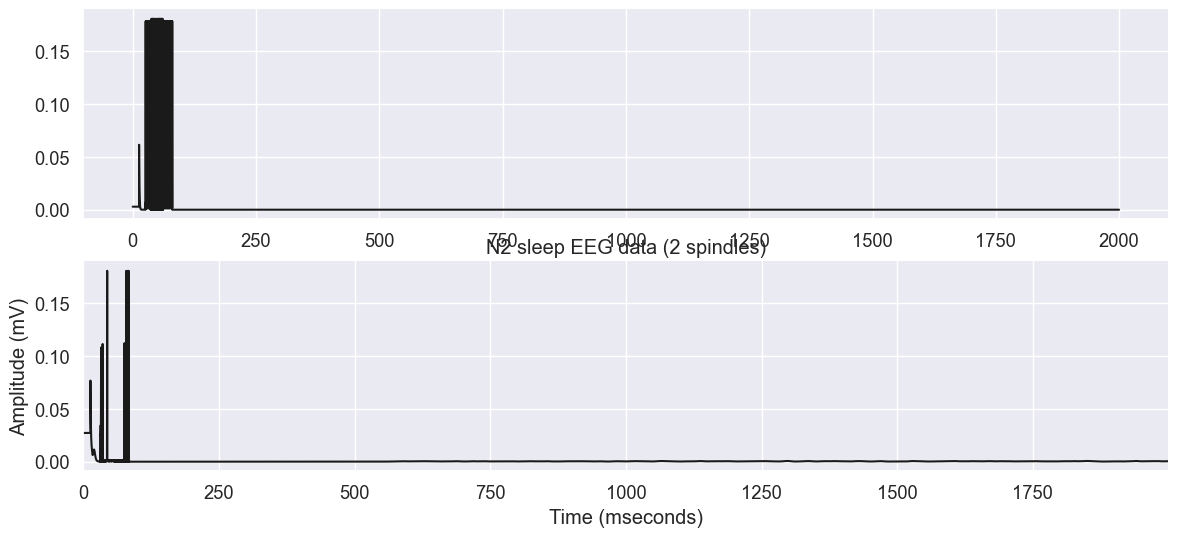

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(2, 1, figsize=(14, 6))
#plt.plot(t[:1000], V_t[:1000], lw=1.5, color='k')
plt.subplot(2,1,1)
plt.plot(t, Q_e, lw=1.5, color='k')
plt.subplot(2,1,2)
plt.plot(t, Q_i, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#
plt.xlim([t.min(), t.max()])
#plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [6]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'aln_thalamus.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

number of cores: 28


In [7]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

KeyboardInterrupt: 

In [ ]:
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.mue_ext_mean'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.mui_ext_mean'].f_get_range()
print(b)



In [ ]:
traj.results.aln_demo_results[0].Q_e.shape

In [ ]:
traj.f_get_explored_parameters().keys()

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

up_state = -int(1000/dt)
def cal_max(i):
    max_rate = np.max(traj.results.aln_demo_results[i].Q_e[up_state:]*1000)
    return max_rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_max)(i) for i in tqdm(range(len(dfResults))))
# plot_results = Parallel(n_jobs=num_cores-14)(delayed(cal_max)(i) for i in range(10))

print(plot_results)


In [ ]:

import matplotlib.pyplot as plt

mues = np.unique(dfResults['mue_ext_mean'])
muis = np.unique(dfResults['mui_ext_mean'])
plot_results_matrix = np.reshape(plot_results, (len(mues), len(muis))).T

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[mues[0], mues[-1], muis[0], muis[-1]])

plt.xlabel("Input to E", fontsize=30)
plt.ylabel("Input to I", fontsize=30)
plt.clim(0, 80)
cbar = plt.colorbar(label="Maximum rate of E(Hz)", extend='max')
plt.show()